In [ ]:
# Upload your activities_master.csv file
from google.colab import files
import pandas as pd
import numpy as np
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("📁 Please upload your activities_master.xlsx file:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {filename}")
print(f"📊 File size: {len(uploaded[filename]):,} bytes")

# Quick preview of the raw data
df_preview = pd.read_excel(filename)
print(f"\n📋 Data shape: {df_preview.shape[0]} activities, {df_preview.shape[1]} columns")
print(f"📅 Date range: {df_preview['Activity Date'].min()} to {df_preview['Activity Date'].max()}")

📁 Please upload your activities_master.xlsx file:


Saving activities_master.xlsx to activities_master.xlsx

✅ Uploaded: activities_master.xlsx
📊 File size: 2,586,430 bytes

📋 Data shape: 8337 activities, 100 columns
📅 Date range: Apr 1, 2020, 1:19:35 PM to Sep 9, 2025, 9:00:13 AM


In [ ]:
# Define all data processing functions

def load_and_initial_clean(filepath):
    """Load the raw Strava CSV and perform initial cleaning."""
    print("Loading data from:", filepath)
    df = pd.read_excel(filepath)
    print(f"Loaded {len(df)} activities with {len(df.columns)} columns")

    # Remove completely empty rows if any
    df = df.dropna(how='all')

    # Convert Activity Date to datetime
    df['Activity Date'] = pd.to_datetime(df['Activity Date'], errors='coerce')

    return df

def select_core_features(df):
    """Select only the core features needed for modeling."""
    # Define core columns to keep (if they exist in the data)
    core_columns = [
        'Name', 'Activity Date', 'Activity Type', 'Moving Time', 'Relative Effort'
    ]

    # Keep only columns that exist in the dataframe
    existing_columns = [col for col in core_columns if col in df.columns]
    df_selected = df[existing_columns].copy()

    print(f"\nSelected {len(existing_columns)} core features from {len(df.columns)} total columns")

    # Handle duplicate column names
    df_selected = df_selected.loc[:, ~df_selected.columns.duplicated()]

    return df_selected

def analyze_missing_data(df):
    """Analyze missing data patterns and create a report."""
    missing_report = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
    })

    missing_report = missing_report.sort_values('Missing_Percentage', ascending=False)
    missing_report['Imputation_Method'] = missing_report['Missing_Percentage'].apply(
        lambda x: 'Dropped (>50% missing)' if x > 50 else 'Mean imputation' if x > 0 else 'No imputation needed'
    )

    return missing_report

def convert_time_to_seconds(time_str):
  """Convert time string (HH:MM:SS or MM:SS) to total seconds."""
  if pd.isna(time_str) or time_str == '':
    return np.nan

  # If it's already numeric, return it
  if isinstance(time_str, (int, float)):
      return float(time_str)

  # Convert string to seconds
  try:
      time_str = str(time_str)
      parts = time_str.split(':')

      if len(parts) == 3:  # HH:MM:SS
          hours, minutes, seconds = parts
          return float(hours) * 3600 + float(minutes) * 60 + float(seconds)
      elif len(parts) == 2:  # MM:SS
          minutes, seconds = parts
          return float(minutes) * 60 + float(seconds)
      elif len(parts) == 1:  # Just seconds
          return float(parts[0])
      else:
          return np.nan
  except:
      return np.nan

def engineer_features(df):
  """Create derived features for better model performance."""
  print("\nEngineering new features...")

  # Convert time columns from string format to seconds if needed
  time_columns = ['Moving Time']
  for col in time_columns:
      if col in df.columns:
          # Check if column is string type
          if df[col].dtype == 'object':
              print(f"  Converting {col} from time string to seconds...")
              df[col] = df[col].apply(convert_time_to_seconds)

  # Convert Distance to numeric if it's not already
  if 'Distance' in df.columns:
      df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')

  # 4. Time-based features
  if 'Activity Date' in df.columns:
      df['weekday'] = df['Activity Date'].dt.dayofweek  # 0=Monday, 6=Sunday
      df['month'] = df['Activity Date'].dt.month
      df['year'] = df['Activity Date'].dt.year
      df['day_of_year'] = df['Activity Date'].dt.dayofyear

  print(f"Created features successfully!")

  return df

def normalize_features(df):
    """Normalize numeric features using z-score normalization."""
    print("\nNormalizing numeric features...")

    # Identify numeric columns to normalize (exclude binary flags and identifiers)
    exclude_from_norm = [
        'is_race', 'has_heart_rate', 'has_power', 'has_cadence',
        'weekday', 'month', 'year', 'day_of_year'
    ]

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    cols_to_normalize = [col for col in numeric_cols if col not in exclude_from_norm]

    # Z-score normalization
    for col in cols_to_normalize:
        if df[col].std() > 0:  # Avoid division by zero
            df[f'{col}_normalized'] = (df[col] - df[col].mean()) / df[col].std()
        else:
            df[f'{col}_normalized'] = 0

    print(f"Normalized {len(cols_to_normalize)} features")

    return df

def create_final_dataset(df):
  """Create the final model-ready dataset by selecting and ordering columns."""
  print("\nCreating final dataset...")

  # Define column order (features first, then target-related)
  priority_cols = ['Name', 'Activity Date', 'Activity Type', 'Moving Time', 'Relative Effort']

  # Get all numeric and engineered features
  feature_cols = [col for col in df.columns if col not in priority_cols]

  # Reorder columns
  final_cols = priority_cols + feature_cols
  final_cols = [col for col in final_cols if col in df.columns]

  df_final = df[final_cols].copy()

  # Sort by Activity Date (most recent first)
  if 'Activity Date' in df_final.columns:
      df_final = df_final.sort_values('Activity Date', ascending=False)

  print(f"Final dataset shape: {df_final.shape}")

  return df_final

In [ ]:
# RUN THE COMPLETE PROCESSING PIPELINE

print("=" * 60)
print("🚀 STRAVA DATA PROCESSING PIPELINE")
print("=" * 60)

# Step 1: Load data
df = load_and_initial_clean(filename)

# Step 2: Select core features
df = select_core_features(df)

# Step 4: Engineer features (no race detection)
df = engineer_features(df)

# # Step 6: Normalize features
# df = normalize_features(df)

# Step 8: Create final dataset
activities = create_final_dataset(df)

# Change all virtual rides to normal rides
activities['Activity Type'] = activities['Activity Type'].replace("Virtual Ride", "Ride")

# Step 9: Save outputs
activities.to_excel('strava_model_ready.xlsx', index=False)

print("\n" + "=" * 60)
print("✅ PROCESSING COMPLETE!")
print("=" * 60)
print(f"\nDataset Summary:")
print(f"  📊 Total training activities: {len(activities)}")
print(f"  🔢 Total features: {len(activities.columns)}")

🚀 STRAVA DATA PROCESSING PIPELINE
Loading data from: activities_master.xlsx
Loaded 8337 activities with 100 columns

Selected 5 core features from 100 total columns

Engineering new features...
Created features successfully!

Creating final dataset...
Final dataset shape: (8337, 9)

✅ PROCESSING COMPLETE!

Dataset Summary:
  📊 Total training activities: 8337
  🔢 Total features: 9


In [ ]:
# Explore the processed data
print("📋 First 5 rows of processed data:")
activities.head()

📋 First 5 rows of processed data:


,Name,Activity Date,Activity Type,Moving Time,Relative Effort,weekday,month,year,day_of_year
6407,Jonathan Ravid,2025-12-07 14:54:18,Run,4402,38.0,6,12,2025,341
8336,Matt Stelmokas,2025-12-06 19:59:34,Run,3181,70.0,5,12,2025,340
6406,Jonathan Ravid,2025-12-06 15:52:02,Ride,10804,74.0,5,12,2025,340
4070,Spencer McGehee,2025-12-05 23:30:07,Ride,7090,87.0,4,12,2025,339
6408,Jonathan Ravid,2025-12-05 23:30:05,Ride,1202,3.0,4,12,2025,339


In [ ]:
# Function definitions for calculating features (see list)
def type_duration(df, type):
  """Calculate the total duration of a given activity type."""
  return df[df['Activity Type'] == type]['Moving Time'].sum()

def weighted_duration(swim, bike, run):
  return 0.3 * swim + 0.4 * bike + 0.3 * run

def num_activities(df):
  return len(df)

def avg_activity_duration(df):
  return df['Moving Time'].mean()



def tot_rel_effort(df):
  return df['Relative Effort'].sum()

def avg_rel_effort(df):
  return df['Relative Effort'].mean()

def var_rel_effort(df):
  return df['Relative Effort'].var()

def frac_high_low_rel_eff(df):
    """
    Fraction of sessions >= 70th percentile and < 70th percentile of Relative Effort
    Computed within the current window only.
    """
    if len(df) == 0:
        return 0.0, 0.0

    re_vals = df['Relative Effort'].dropna()
    if len(re_vals) == 0:
        return 0.0, 0.0

    thresh = np.percentile(re_vals, 70)



    high = np.sum(re_vals >= thresh)
    low  = np.sum(re_vals < thresh)


    result = 0;

    if low == 0:
      result = 100
    else:
      result = high / low


    return result

def acute_rel_eff_7d(df):
    """7-day rolling (acute) Relative Effort prior to race"""
    if len(df) == 0:
        return 0.0

    df_sorted = df.sort_values("Activity Date")
    cutoff_date = df_sorted["Activity Date"].max() - pd.Timedelta(days=7)

    df_7d = df_sorted[df_sorted["Activity Date"] >= cutoff_date]

    return df_7d["Relative Effort"].sum()

def chronic_rel_eff_42d(df):
    """42-day rolling (chronic) Relative Effort prior to race"""
    if len(df) == 0:
        return 0.0

    df_sorted = df.sort_values("Activity Date")
    cutoff_date = df_sorted["Activity Date"].max() - pd.Timedelta(days=42)

    df_42d = df_sorted[df_sorted["Activity Date"] >= cutoff_date]

    return df_42d["Relative Effort"].sum()

def total_stress_balance(chronic, acute):
    """Normalized TSB = (chronic - acute) / (chronic + 1)"""
    return (chronic - acute) / (chronic + 1)


# ..... continue implementing feature definitions

def compute_features(df):
  swim = type_duration(df, "Swim")
  bike = type_duration(df, "Ride")
  run  = type_duration(df, "Run")

  chronic = chronic_rel_eff_42d(df)
  acute = acute_rel_eff_7d(df)

  return {
    "swim_duration": type_duration(df, "Swim"),
    "bike_duration": type_duration(df, "Ride"),
    "run_duration": type_duration(df, "Run"),
    # # "weighted_duration": weighted_duration(swim, bike, run),
    # "num_acts": num_activities(df),
    # "avg_act_duration": avg_activity_duration(df),

    # "total_rel_eff": tot_rel_effort(df),
    "avg_rel_eff": avg_rel_effort(df),
    # "var_rel_eff": var_rel_effort(df),
    # # add your others...
    "total_stress_balance": total_stress_balance(chronic, acute),

  }


In [ ]:
# Import race data as target vector

print("📁 Please upload your race spreadsheet (e.g. race_times_master.xlsx):")
uploaded = files.upload()

race_filename = list(uploaded.keys())[0]
print(f"\n✅ Loaded race file: {race_filename}")

races = pd.read_excel(race_filename)
print(f"📊 Race dataset shape: {races.shape}")

📁 Please upload your race spreadsheet (e.g. race_times_master.xlsx):


Saving race_times_master.xlsx to race_times_master (2).xlsx

✅ Loaded race file: race_times_master (2).xlsx
📊 Race dataset shape: (49, 12)


In [ ]:
# Clean race data

# change dates to datetime and times to seconds

def time_to_seconds(t):
    if pd.isna(t):
        return np.nan
    if isinstance(t, (int, float)):
        return t
    parts = str(t).split(':')
    if len(parts) == 3:
        h, m, s = parts
        return int(h)*3600 + int(m)*60 + float(s)
    elif len(parts) == 2:
        m, s = parts
        return int(m)*60 + float(s)
    return np.nan

# Apply conversions
for col in ['swim', 't1', 'bike', 't2', 'run', 'total']:
    races[col] = races[col].apply(time_to_seconds)

races['date'] = pd.to_datetime(races['date'])

races.head(20)

,athlete_name,season,race_name,swim,t1,bike,t2,run,total,date,on_strava,notes
0,Andrew Bickford,2023–24,Cal Tri Williamsburg,1885.0,149.0,3672.0,60.0,2261.0,8669.0,2023-07-23,yes,NaN
1,Andrew Bickford,2023–24,Giant Acorn Olympic,1778.0,115.0,4646.0,103.0,2269.0,8911.0,2023-09-23,partially,NaN
2,Andrew Bickford,2023–24,"USAT Collegiate Nationals – Mission Viejo, CA ...",1592.0,69.0,4161.0,74.0,2168.0,8063.0,2024-04-14,yes,NaN
3,Andrew Bickford,2024–25,USAT Collegiate Nationals – Miami (Olympic),1760.0,120.0,4169.0,89.0,2079.0,8216.0,2025-03-29,yes,NaN
4,Andrew Bickford,2025–26,Giant Acorn Olympic,1687.0,111.0,4116.0,66.0,2126.0,8103.0,2025-09-21,yes,NaN
5,Spencer McGhee,2021,2021 Kinetic Cup Triathlon Festival,NaN,NaN,NaN,NaN,NaN,8012.0,2021-10-16,NaN,NaN
6,Spencer McGhee,2021,2021 Giant Acorn Triathlon Festival,NaN,NaN,NaN,NaN,NaN,8514.0,2021-09-25,NaN,NaN
7,Spencer McGhee,2022,2022 Kinetic Cup Triathlon Festival,NaN,NaN,NaN,NaN,NaN,7738.0,2022-10-15,NaN,NaN
8,Spencer McGhee,2022,2022 Giant Acorn Triathlon Festival,NaN,NaN,NaN,NaN,NaN,8153.0,2022-09-24,NaN,NaN
9,Spencer McGhee,2022,2022 Collegiate Club National Championships,NaN,NaN,NaN,NaN,NaN,8284.0,2022-04-02,NaN,"half swim, 2:05:36 imputed to 2:18:04"


In [ ]:
# For each race, create a high dimensional feature vector.
# To do this for each race in races create 30, 60, and 90 day dataframe of activites filtered from 'activities' above.
# Within each dataframe, compute features using function definitions above.

all_features = []

for race in races.itertuples():
  athlete = race.athlete_name
  race_date = race.date

  # Filter all activities for the athlete
  acts = activities[activities['Name'] == athlete]

  # Define the windows
  window_defs = {
    "30": 30,
  }

  race_features = {
    "race_name": race.race_name,
    "race_date": race_date,
    "athlete_name": athlete,
    "target_time": race.total,   # if you want a supervised target
  }

  # Compute window-specific features
  for key, days in window_defs.items():
      df_window = acts[
        (acts['Activity Date'] >= race_date - pd.Timedelta(days=days)) &
        (acts['Activity Date'] < race_date)
      ]

      feats = compute_features(df_window)

      # Prefix each feature with the window length
      for feat_name, value in feats.items():
        race_features[f"{key}d_{feat_name}"] = value

  all_features.append(race_features)

# Convert to features DataFrame
features_df = pd.DataFrame(all_features)

features_df.drop(columns=['race_name', 'race_date', 'athlete_name'], inplace=True)

# display for debugging / preview
features_df.head()

# list(features_df.columns)

,target_time,30d_swim_duration,30d_bike_duration,30d_run_duration,30d_avg_rel_eff,30d_total_stress_balance
0,8669.0,1757,17764,62193,65.933333,0.747347
1,8911.0,3577,32638,50772,79.500000,0.806093
2,8063.0,12865,47572,37443,49.344828,0.770950
3,8216.0,8263,14937,22435,30.923077,0.759006
4,8103.0,12853,37550,31668,54.766667,0.700730


7982.598122448979
[0]	train-rmse:401.33875	eval-rmse:625.34378
[50]	train-rmse:238.23660	eval-rmse:548.84044
[100]	train-rmse:183.38033	eval-rmse:501.56580
[150]	train-rmse:158.42256	eval-rmse:489.20763
[200]	train-rmse:146.55012	eval-rmse:483.18039
[250]	train-rmse:139.98249	eval-rmse:478.26465
[295]	train-rmse:137.40852	eval-rmse:478.55736
[8001.483  8045.192  7323.2812 7910.464  8314.6    8073.6196 8059.231
 7827.429  7611.293  8107.349 ]
Validation RMSE: 478.5573791729073
Validation R²: 0.3513129903797514


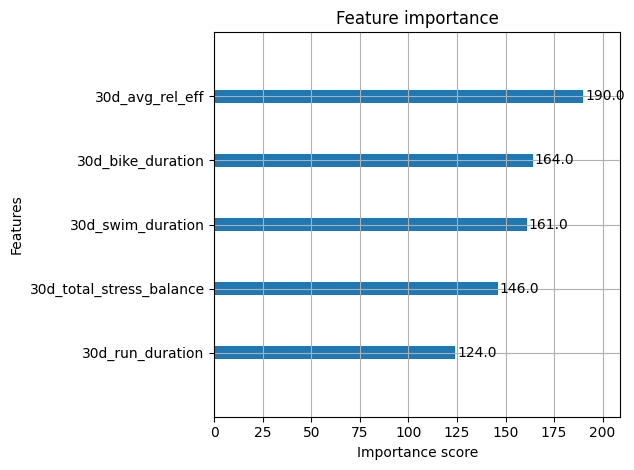

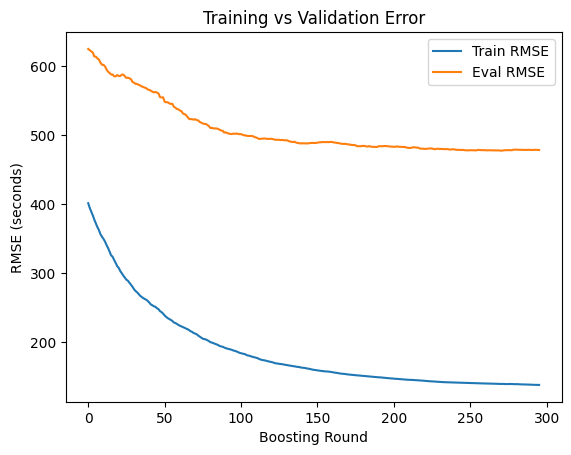

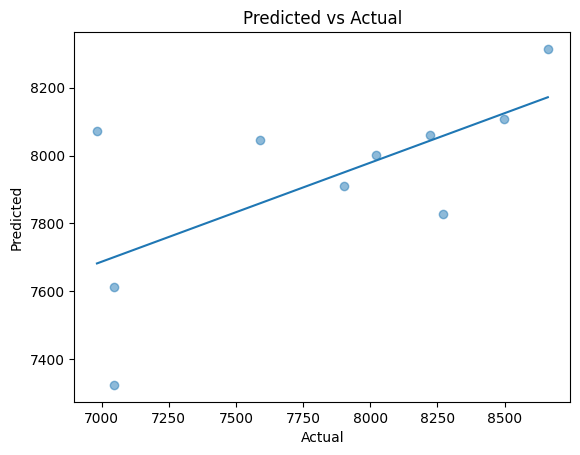

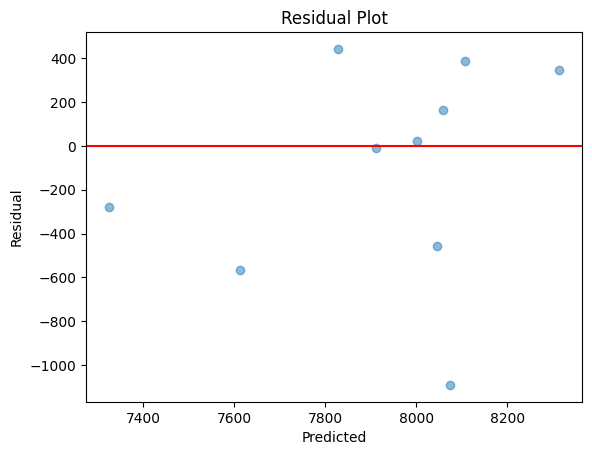

In [ ]:
# skeleton code for xgboost

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


# -----------------------------------------------------
# 1. Create dummy data with 50 features
# -----------------------------------------------------
X = features_df.drop(columns=['target_time'])
y = features_df['target_time']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(features_df['target_time'].mean())

# Turn into XGBoost DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(X.columns))
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=list(X.columns))

# -----------------------------------------------------
# 2. Define training parameters (learn-style)
# -----------------------------------------------------
params = {
    "objective": "reg:squarederror",
    "eta": 0.05,              # learning rate
    "max_depth": 2,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "rmse"
}

num_rounds = 300

# -----------------------------------------------------
# 3. Train model w/ validation
# -----------------------------------------------------
watchlist = [(dtrain, "train"), (dtest, "eval")]

eval_history = {}

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=num_rounds,
    evals=watchlist,
    early_stopping_rounds=25,
    evals_result=eval_history,
    verbose_eval=50  # shows progress every 50 rounds
)

# -----------------------------------------------------
# 4. Evaluate on test set
# -----------------------------------------------------
preds = model.predict(dtest)
print(preds)

rmse = mean_squared_error(y_test, preds) ** 0.5
r2 = r2_score(y_test, preds)

print("Validation RMSE:", rmse)
print("Validation R²:", r2)

xgb.plot_importance(model)
plt.tight_layout()
plt.show()


train_rmse = eval_history["train"]["rmse"]
eval_rmse  = eval_history["eval"]["rmse"]
plt.plot(train_rmse, label="Train RMSE")
plt.plot(eval_rmse, label="Eval RMSE")
plt.legend()
plt.xlabel("Boosting Round")
plt.ylabel("RMSE (seconds)")
plt.title("Training vs Validation Error")
plt.show()


plt.scatter(y_test, preds, alpha=0.5)

m, b = np.polyfit(y_test, preds, 1)
x_line = np.linspace(min(y_test), max(y_test), 100)
y_line = m * x_line + b
plt.plot(x_line, y_line)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()


residuals = y_test - preds
plt.scatter(preds, residuals, alpha=0.5)
plt.axhline(0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()